Import Libraries

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Load Dataset

In [37]:
df = pd.read_csv("/content/creditcard.csv")

Data Cleaning

In [38]:
df = df.drop_duplicates()
# Drop rows with NaN values in 'Time', 'Amount', or 'Class' as they are used in the model
df.dropna(subset=["Time", "Amount", "Class"], inplace=True)
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Descriptive Statistics

In [39]:
print(df["Class"].value_counts())
print(df["Amount"].describe())

Class
0.0    39418
1.0      104
Name: count, dtype: int64
count    39522.000000
mean        87.630658
std        234.943913
min          0.000000
25%          7.380000
50%         23.660000
75%         79.155000
max       7879.420000
Name: Amount, dtype: float64


Fraud Analysis

In [40]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

print("Fraud Transactions:", len(fraud))
print("Normal Transactions:", len(normal))

Fraud Transactions: 104
Normal Transactions: 39418


Visualization

Fraud Distribution

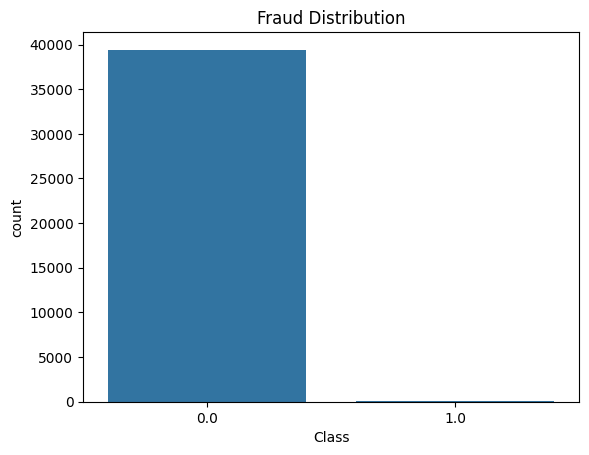

In [41]:
sns.countplot(x="Class", data=df)
plt.title("Fraud Distribution")
plt.show()

Transaction Amount Distribution

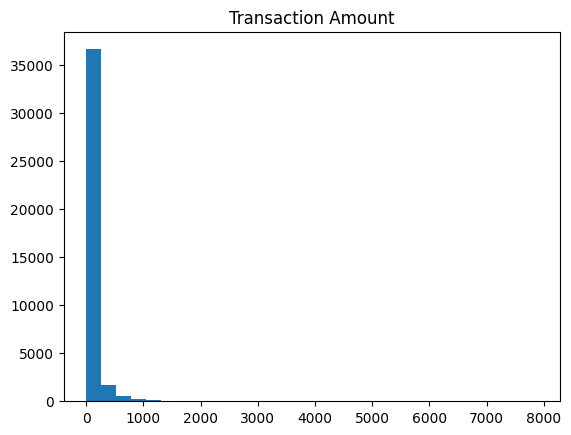

In [42]:
plt.hist(df["Amount"], bins=30)
plt.title("Transaction Amount")
plt.show()

 Correlation Heatmap

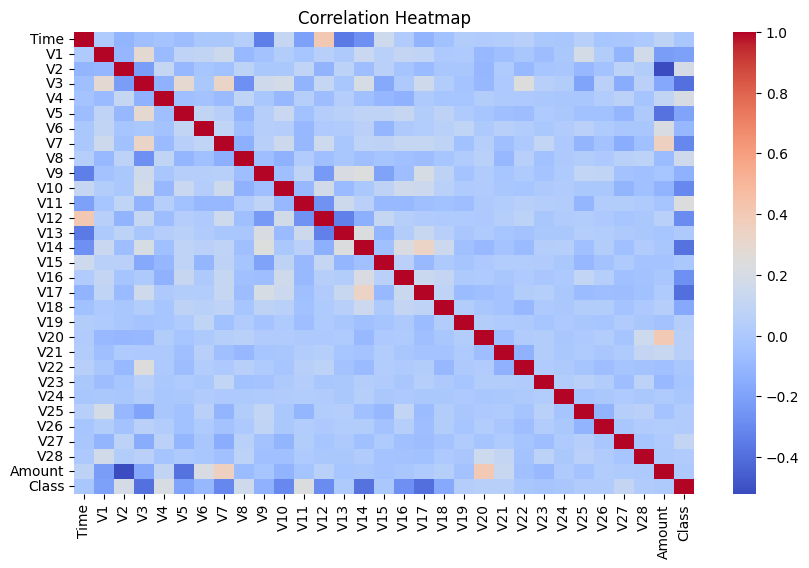

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Risk Analysis

In [44]:
def risk(amount):
    if amount < 100:
        return "Low Risk"
    elif amount < 1000:
        return "Medium Risk"
    else:
        return "High Risk"

df["Risk"] = df["Amount"].apply(risk)

print(df[["Amount", "Risk"]].head())

   Amount         Risk
0  149.62  Medium Risk
1    2.69     Low Risk
2  378.66  Medium Risk
3  123.50  Medium Risk
4   69.99     Low Risk


 Linear Regression Model



Independent Variables

In [45]:
X = df[["Time", "Amount"]]

Dependent Variable

In [46]:
y = df["Class"]

Split Data

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

 Prediction


In [48]:
y_pred = model.predict(X_test)

Model Evaluation


In [49]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.0003395462497253199


 Conclusion


In [50]:
print("\nFraud detection analysis completed successfully.")


Fraud detection analysis completed successfully.
